# Part 1

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
data = pd.read_csv("spambase/spambase.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

In [5]:
def compute_metrics(y_true, y_pred, y_prob):
    error = 1 - accuracy_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return error, acc, f1, auc

In [6]:
train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob)
test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

# Print results
print("Training Metrics:")
print(f"Error: {train_metrics[0]:.4f}")
print(f"Accuracy: {train_metrics[1]:.4f}")
print(f"F1 Score: {train_metrics[2]:.4f}")
print(f"AUC: {train_metrics[3]:.4f}")

print("\nTesting Metrics:")
print(f"Error: {test_metrics[0]:.4f}")
print(f"Accuracy: {test_metrics[1]:.4f}")
print(f"F1 Score: {test_metrics[2]:.4f}")
print(f"AUC: {test_metrics[3]:.4f}")

Training Metrics:
Error: 0.0005
Accuracy: 0.9995
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics:
Error: 0.0684
Accuracy: 0.9316
F1 Score: 0.9176
AUC: 0.9286


# Part 2

In [7]:
model_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gini.fit(X_train, y_train)

y_train_pred_g = model_gini.predict(X_train)
y_test_pred_g = model_gini.predict(X_test)

y_train_prob_g = model_gini.predict_proba(X_train)[:, 1]
y_test_prob_g = model_gini.predict_proba(X_test)[:, 1]

train_metrics_g = compute_metrics(y_train, y_train_pred_g, y_train_prob_g)
test_metrics_g = compute_metrics(y_test, y_test_pred_g, y_test_prob_g)

In [8]:
print("Training Metrics (Gini):")
print(f"Error: {train_metrics_g[0]:.4f}")
print(f"Accuracy: {train_metrics_g[1]:.4f}")
print(f"F1 Score: {train_metrics_g[2]:.4f}")
print(f"AUC: {train_metrics_g[3]:.4f}")

print("\nTesting Metrics (Gini):")
print(f"Error: {test_metrics_g[0]:.4f}")
print(f"Accuracy: {test_metrics_g[1]:.4f}")
print(f"F1 Score: {test_metrics_g[2]:.4f}")
print(f"AUC: {test_metrics_g[3]:.4f}")

Training Metrics (Gini):
Error: 0.0005
Accuracy: 0.9995
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics (Gini):
Error: 0.0814
Accuracy: 0.9186
F1 Score: 0.9020
AUC: 0.9176


# Part 3

In [9]:
depths = range(1, 21)

train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeClassifier(
        criterion="entropy", 
        max_depth=d, 
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

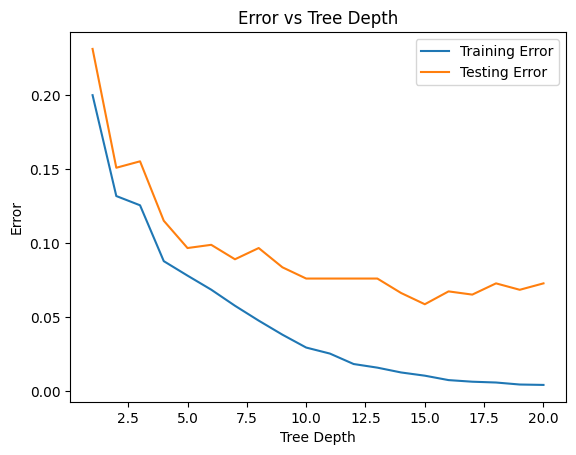

In [10]:
import matplotlib.pyplot as plt

plt.plot(depths, train_errors, label="Training Error")
plt.plot(depths, test_errors, label="Testing Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")
plt.legend()
plt.show()